# QBUS2820 Assignment 1 — Predicting Weekly Rent

**Student ID:** `SID`  *(TODO: replace, and rename this file / the prediction CSV accordingly)*

This notebook implements the full analysis:

1. Setup and data loading
2. Exploratory data analysis (EDA)
3. Validation design (K-fold cross-validation)
4. Candidate models, from simple to flexible
5. Model comparison
6. Final model: refit on all training data, diagnostics, test predictions
7. Marker-only final cell (computes the test MSE — **not executed by the student**)

`WeeklyRent_training.csv` and `WeeklyRent_test_noLabel.csv` must be in the same folder as this notebook.

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer, FunctionTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
SEED = 0                      # fixed seed for reproducibility
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")   # report numbers to 4 d.p.

In [2]:
train = pd.read_csv("WeeklyRent_training.csv")
test_X = pd.read_csv("WeeklyRent_test_noLabel.csv")

TARGET = "WeeklyRent"
FEATURES = [c for c in train.columns if c != TARGET]
CONTINUOUS = ["DistanceCBD", "FloorArea", "PropertyAge"]
DISCRETE = ["Bedrooms"]
BINARY = ["NearTrain", "Furnished", "HighDemandArea"]

X = train[FEATURES]
y = train[TARGET]
print("Training:", train.shape, " Test (no label):", test_X.shape)
train.head()

Training: (5000, 8)  Test (no label): (1000, 7)


,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea
0,774.3000,1.5700,1,49.1000,24.9000,0,1,0
1,980.1000,12.3300,2,96.1000,14.0000,1,0,1
2,686.1400,23.7000,2,82.0000,1.1000,0,1,0
3,968.3900,6.8500,1,59.9000,12.3000,1,1,1
4,849.0600,19.8800,3,93.5000,8.0000,1,0,0


## 2. Exploratory data analysis

### 2.1 Data quality: summary statistics, missing values, duplicates, boundary values

In [3]:
display(train.describe().T)
print("Missing values (train):", int(train.isna().sum().sum()), "| (test):", int(test_X.isna().sum().sum()))
print("Duplicated rows (train):", int(train.duplicated().sum()))

,count,mean,std,min,25%,50%,75%,max
WeeklyRent,5000.0000,860.6811,215.4138,194.2600,703.0750,849.0900,1003.3525,1741.4000
DistanceCBD,5000.0000,13.5099,9.5587,0.6200,5.4300,11.4150,20.0900,40.0000
Bedrooms,5000.0000,2.3628,1.0902,1.0000,2.0000,2.0000,3.0000,5.0000
FloorArea,5000.0000,87.8890,30.1933,35.0000,65.0000,85.7000,108.2250,191.2000
PropertyAge,5000.0000,19.7222,14.1877,0.1000,9.2750,16.4000,26.6000,100.0000
NearTrain,5000.0000,0.4620,0.4986,0.0000,0.0000,0.0000,1.0000,1.0000
Furnished,5000.0000,0.2998,0.4582,0.0000,0.0000,0.0000,1.0000,1.0000
HighDemandArea,5000.0000,0.4562,0.4981,0.0000,0.0000,0.0000,1.0000,1.0000


Missing values (train): 0 | (test): 0
Duplicated rows (train): 0


In [4]:
# Possible censoring / boundary values: many observations sit exactly at the min or max
for c in CONTINUOUS:
    lo, hi = train[c].min(), train[c].max()
    print(f"{c:12s} min={lo:8.2f} (n={int((train[c] == lo).sum()):3d})   "
          f"max={hi:8.2f} (n={int((train[c] == hi).sum()):3d})")
# TODO: discuss what these boundary values mean (e.g. DistanceCBD capped at 40 km, FloorArea floored at 35 m^2)

DistanceCBD  min=    0.62 (n=  1)   max=   40.00 (n= 43)
FloorArea    min=   35.00 (n=106)   max=  191.20 (n=  1)
PropertyAge  min=    0.10 (n=  1)   max=  100.00 (n=  2)


### 2.2 Distribution of the response

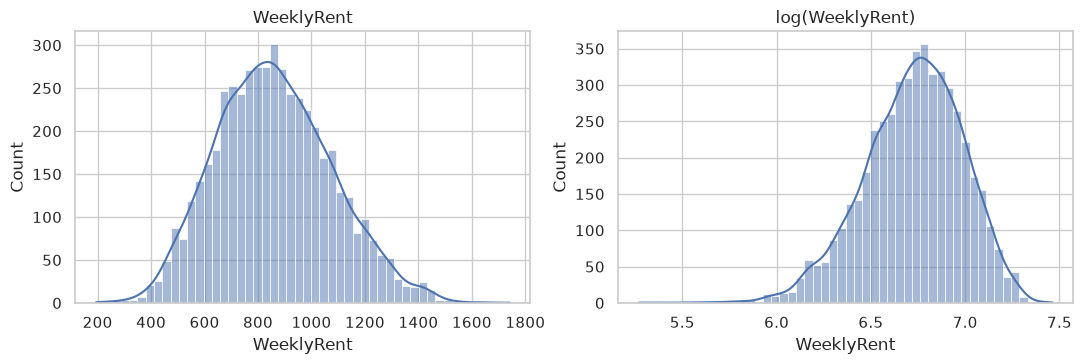

Skewness: 0.2660


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(y, bins=50, kde=True, ax=ax[0]).set_title("WeeklyRent")
sns.histplot(np.log(y), bins=50, kde=True, ax=ax[1]).set_title("log(WeeklyRent)")
plt.tight_layout(); plt.show()
print(f"Skewness: {y.skew():.4f}")

### 2.3 Response vs. continuous predictors (with LOWESS smoother to reveal non-linearity)

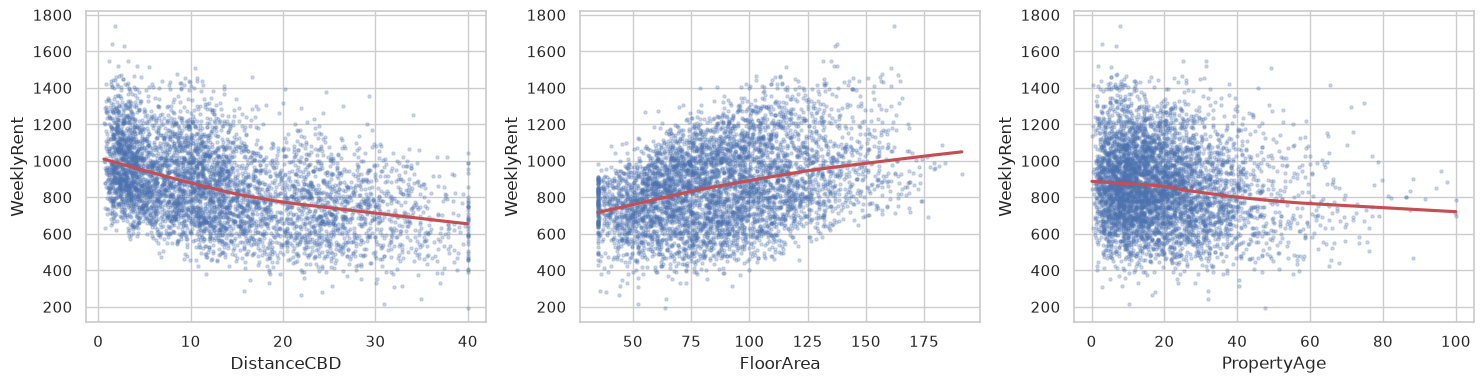

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, CONTINUOUS):
    sns.regplot(x=train[c], y=y, lowess=True, ax=ax,
                scatter_kws=dict(s=5, alpha=0.25), line_kws=dict(color="C3"))
plt.tight_layout(); plt.show()

### 2.4 Response vs. discrete / binary predictors

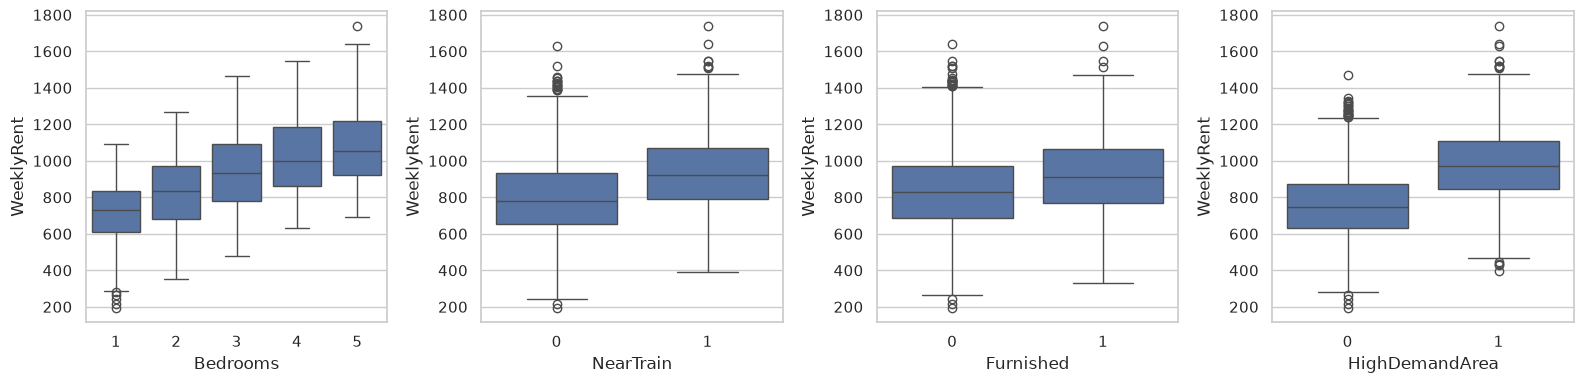

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, c in zip(axes, DISCRETE + BINARY):
    sns.boxplot(x=train[c], y=y, ax=ax)
plt.tight_layout(); plt.show()

### 2.5 Correlations (multicollinearity check)

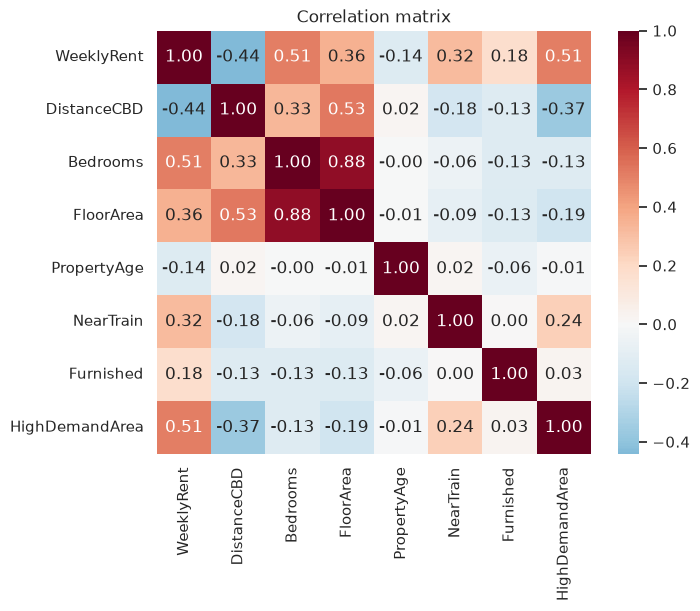

In [8]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation matrix"); plt.show()

### 2.6 Interaction checks
If the slope of one predictor changes across levels of another, the model needs interaction terms.

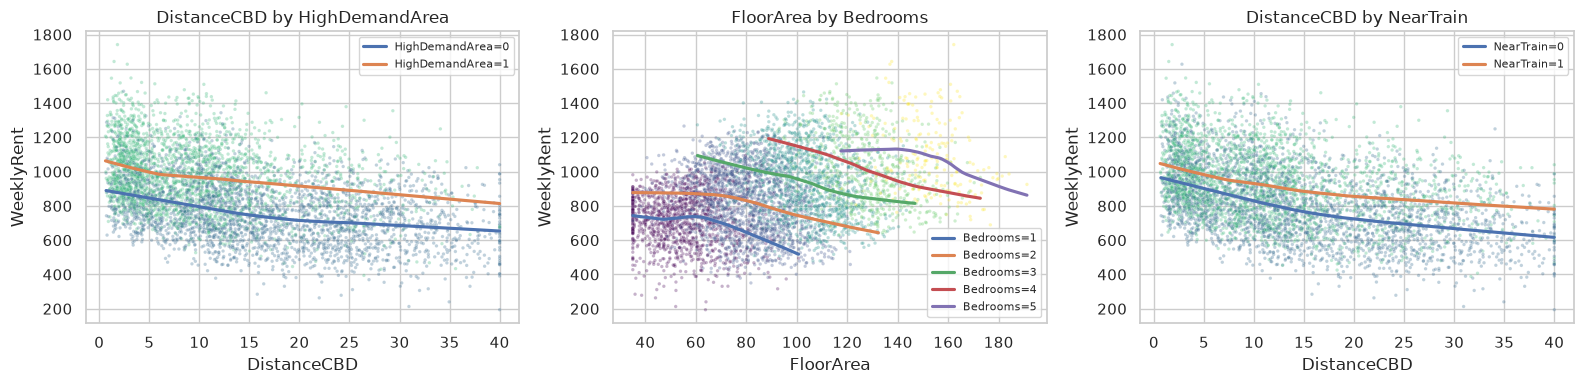

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pairs = [("DistanceCBD", "HighDemandArea"), ("FloorArea", "Bedrooms"), ("DistanceCBD", "NearTrain")]
for ax, (xv, grp) in zip(axes, pairs):
    sns.scatterplot(x=train[xv], y=y, hue=train[grp], s=6, alpha=0.3, palette="viridis", ax=ax, legend=False)
    for g, sub in train.groupby(grp):
        sns.regplot(x=sub[xv], y=sub[TARGET], lowess=True, scatter=False, ax=ax, label=f"{grp}={g}")
    ax.legend(fontsize=8); ax.set_title(f"{xv} by {grp}")
plt.tight_layout(); plt.show()
# TODO: add any other interactions you want to examine

### 2.7 Residuals of a plain linear model
Systematic patterns in OLS residuals against each predictor indicate missing non-linear terms.

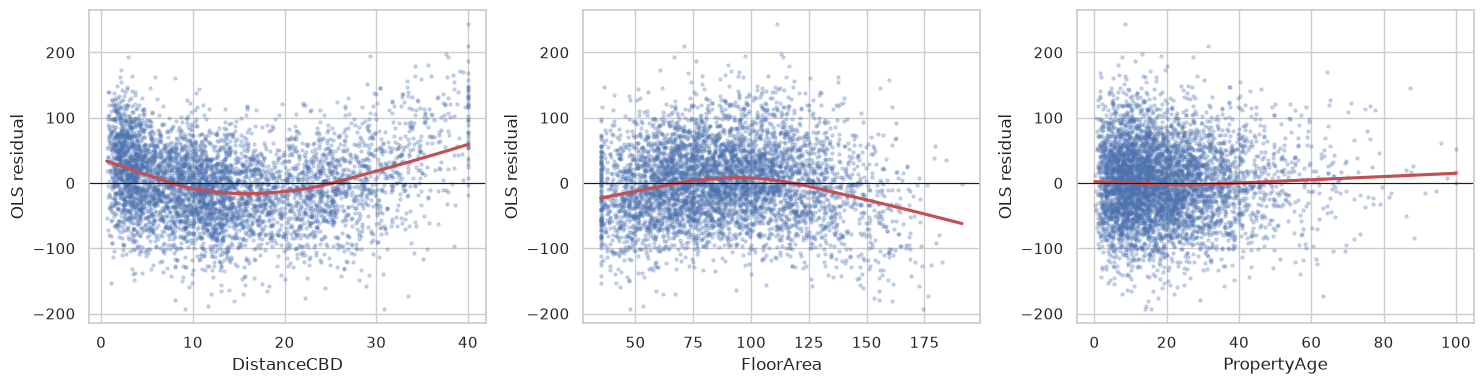

In [10]:
ols_resid = y - LinearRegression().fit(X, y).predict(X)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, CONTINUOUS):
    sns.regplot(x=train[c], y=ols_resid, lowess=True, ax=ax,
                scatter_kws=dict(s=5, alpha=0.25), line_kws=dict(color="C3"))
    ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("OLS residual")
plt.tight_layout(); plt.show()

**EDA summary (TODO — write your own findings):**
- ...
- ...

## 3. Validation design

The test labels are unavailable, so every model is compared by **10-fold cross-validated MSE** on the training set.
All preprocessing (scaling, basis expansion) lives inside a `Pipeline`, so it is re-fitted within each fold (no leakage).
For models with hyper-parameters, `GridSearchCV` uses the same folds; its best CV score is slightly optimistic,
which should be acknowledged in the report.

In [11]:
cv = KFold(n_splits=10, shuffle=True, random_state=SEED)
results = {}

def evaluate(name, model, X_=X):
    # Record the 10-fold CV MSE (mean and standard error) of a model
    mse = -cross_val_score(model, X_, y, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1)
    results[name] = dict(CV_MSE=mse.mean(), SE=mse.std(ddof=1) / np.sqrt(len(mse)))
    print(f"{name:40s} CV MSE = {mse.mean():12.4f}  (SE {results[name]['SE']:.4f})")
    return model

def evaluate_search(name, search):
    # Fit a GridSearchCV object and record its best CV MSE
    search.fit(X, y)
    i = search.best_index_
    mse_mean = -search.cv_results_["mean_test_score"][i]
    se = search.cv_results_["std_test_score"][i] / np.sqrt(cv.get_n_splits())
    results[name] = dict(CV_MSE=mse_mean, SE=se)
    print(f"{name:40s} CV MSE = {mse_mean:12.4f}  (SE {se:.4f})  best = {search.best_params_}")
    return search.best_estimator_

## 4. Candidate models

### 4.1 Baselines

In [12]:
evaluate("Mean (null model)", DummyRegressor())
evaluate("OLS (all predictors)", LinearRegression())

Mean (null model)                        CV MSE =   46419.9486  (SE 901.5884)
OLS (all predictors)                     CV MSE =    3299.9658  (SE 43.6915)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
knn = evaluate_search(
    "KNN (standardised, tuned k)",
    GridSearchCV(make_pipeline(StandardScaler(), KNeighborsRegressor()),
                 {"kneighborsregressor__n_neighbors": [5, 10, 15, 20, 30, 50],
                  "kneighborsregressor__weights": ["uniform", "distance"]},
                 cv=cv, scoring="neg_mean_squared_error", n_jobs=-1))

KNN (standardised, tuned k)              CV MSE =    3278.3188  (SE 72.8419)  best = {'kneighborsregressor__n_neighbors': 10, 'kneighborsregressor__weights': 'distance'}


### 4.2 Linear models with non-linear terms and interactions
Motivated by the curved OLS residuals (Section 2.7) and the interaction plots (Section 2.6).

In [14]:
ALPHAS = np.logspace(-4, 3, 40)

def poly_pipe(degree, reg):
    return make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), reg)

evaluate("Poly(2) + OLS", poly_pipe(2, LinearRegression()))
evaluate("Poly(2) + Ridge", poly_pipe(2, RidgeCV(alphas=ALPHAS)))
evaluate("Poly(3) + Ridge", poly_pipe(3, RidgeCV(alphas=ALPHAS)))
evaluate("Poly(3) + Lasso", poly_pipe(3, LassoCV(alphas=ALPHAS, cv=5, max_iter=50000)))

Poly(2) + OLS                            CV MSE =    2018.5546  (SE 24.5511)


Poly(2) + Ridge                          CV MSE =    2018.6005  (SE 24.4562)


Poly(3) + Ridge                          CV MSE =    2048.5631  (SE 25.9464)


Poly(3) + Lasso                          CV MSE =    2027.2317  (SE 26.2868)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomialfeatures', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### 4.3 Hand-crafted features
Feature engineering is wrapped in a function inside the pipeline, so the fitted model takes the **raw** columns
(this is what the marker-only final cell relies on).

In [15]:
def add_features(df):
    # Create engineered predictors from the raw columns. TODO: extend based on your EDA.
    df = df.copy()
    df["logDistance"] = np.log(df["DistanceCBD"])
    df["AreaPerBedroom"] = df["FloorArea"] / df["Bedrooms"]
    df["DistCapped"] = (df["DistanceCBD"] >= 40).astype(int)      # boundary indicator
    df["Dist_x_HighDemand"] = df["DistanceCBD"] * df["HighDemandArea"]
    return df

feat = FunctionTransformer(add_features)
evaluate("Engineered features + OLS", make_pipeline(feat, LinearRegression()))
evaluate("Engineered + Poly(2) + Ridge",
         make_pipeline(feat, PolynomialFeatures(2, include_bias=False), StandardScaler(), RidgeCV(alphas=ALPHAS)))

Engineered features + OLS                CV MSE =    2886.3753  (SE 47.4551)


Engineered + Poly(2) + Ridge             CV MSE =    2039.0109  (SE 26.3101)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('functiontransformer', ...), ('polynomialfeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x7fd3a1131800>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict

### 4.4 Regression splines (+ quadratic interactions)
Splines let each continuous predictor have a flexible shape; the quadratic block supplies pairwise interactions.

In [16]:
def spline_pipe(n_knots):
    ct = ColumnTransformer([
        ("spline", SplineTransformer(n_knots=n_knots, degree=3), CONTINUOUS),
        ("poly2", PolynomialFeatures(2, include_bias=False), FEATURES),
    ])
    return make_pipeline(ct, StandardScaler(), RidgeCV(alphas=ALPHAS))

for k in [4, 6, 8]:
    evaluate(f"Spline(knots={k}) + Poly(2) + Ridge", spline_pipe(k))

Spline(knots=4) + Poly(2) + Ridge        CV MSE =    2022.7910  (SE 24.9474)


Spline(knots=6) + Poly(2) + Ridge        CV MSE =    2027.4173  (SE 26.6081)


Spline(knots=8) + Poly(2) + Ridge        CV MSE =    2028.0250  (SE 27.9405)


### 4.5 Tree-based models

In [17]:
tree = evaluate_search(
    "Regression tree (tuned)",
    GridSearchCV(DecisionTreeRegressor(random_state=SEED),
                 {"max_depth": [4, 6, 8, 10, None], "min_samples_leaf": [5, 10, 20, 50]},
                 cv=cv, scoring="neg_mean_squared_error", n_jobs=-1))

Regression tree (tuned)                  CV MSE =    4227.8558  (SE 69.5483)  best = {'max_depth': None, 'min_samples_leaf': 5}


In [18]:
rf = evaluate_search(
    "Random forest (tuned)",
    GridSearchCV(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
                 {"max_features": [0.33, 0.66, 1.0], "min_samples_leaf": [1, 5, 10]},
                 cv=cv, scoring="neg_mean_squared_error", n_jobs=-1))

Random forest (tuned)                    CV MSE =    2665.9045  (SE 33.5292)  best = {'max_features': 0.33, 'min_samples_leaf': 1}


In [19]:
gb = evaluate_search(
    "Gradient boosting (tuned)",
    GridSearchCV(HistGradientBoostingRegressor(max_iter=1000, early_stopping=False, random_state=SEED),
                 {"learning_rate": [0.02, 0.05], "max_leaf_nodes": [7, 15],
                  "min_samples_leaf": [20, 50], "max_iter": [500, 1000]},
                 cv=cv, scoring="neg_mean_squared_error", n_jobs=-1))

Gradient boosting (tuned)                CV MSE =    2220.9014  (SE 38.4558)  best = {'learning_rate': 0.05, 'max_iter': 500, 'max_leaf_nodes': 7, 'min_samples_leaf': 20}


### 4.6 Model averaging (optional)
Average the out-of-fold predictions of the best few models and check whether CV MSE improves.

In [20]:
# TODO: choose which models to combine after looking at the comparison table below
ensemble_members = {
    "Poly(2) + Ridge": poly_pipe(2, RidgeCV(alphas=ALPHAS)),
    "Spline(knots=4) + Poly(2) + Ridge": spline_pipe(4),
    "Gradient boosting (tuned)": gb,
}
oof = {n: cross_val_predict(m, X, y, cv=cv, n_jobs=-1) for n, m in ensemble_members.items()}
fold_mse = [mean_squared_error(y.iloc[te], np.mean([oof[n][te] for n in oof], axis=0))
            for _, te in cv.split(X)]
results["Average of " + ", ".join(ensemble_members)] = dict(
    CV_MSE=np.mean(fold_mse), SE=np.std(fold_mse, ddof=1) / np.sqrt(len(fold_mse)))
print(f"Ensemble CV MSE = {np.mean(fold_mse):.4f}")

Ensemble CV MSE = 2040.9019


## 5. Model comparison

,CV_MSE,SE,CV_RMSE
Poly(2) + OLS,2018.5546,24.5511,44.9283
Poly(2) + Ridge,2018.6005,24.4562,44.9288
Spline(knots=4) + Poly(2) + Ridge,2022.7910,24.9474,44.9754
Poly(3) + Lasso,2027.2317,26.2868,45.0248
Spline(knots=6) + Poly(2) + Ridge,2027.4173,26.6081,45.0269
Spline(knots=8) + Poly(2) + Ridge,2028.0250,27.9405,45.0336
Engineered + Poly(2) + Ridge,2039.0109,26.3101,45.1554
"Average of Poly(2) + Ridge, Spline(knots=4) + Poly(2) + Ridge, Gradient boosting (tuned)",2040.9019,27.8212,45.1763
Poly(3) + Ridge,2048.5631,25.9464,45.2611
Gradient boosting (tuned),2220.9014,38.4558,47.1264


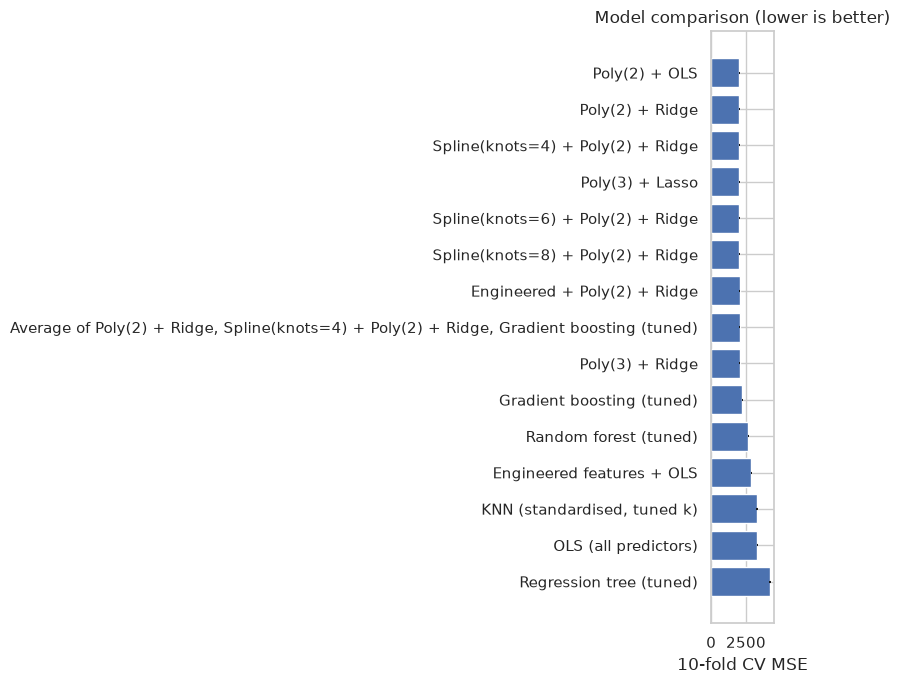

In [21]:
res = (pd.DataFrame(results).T.sort_values("CV_MSE")
       .assign(CV_RMSE=lambda d: np.sqrt(d.CV_MSE)))
display(res)

plot_res = res.drop(index="Mean (null model)")
plt.figure(figsize=(8, 0.4 * len(plot_res) + 1))
plt.barh(plot_res.index[::-1], plot_res.CV_MSE[::-1], xerr=plot_res.SE[::-1], color="C0")
plt.xlabel("10-fold CV MSE"); plt.title("Model comparison (lower is better)")
plt.tight_layout(); plt.show()

**Model choice (TODO):** explain which model you pick and why (CV MSE, standard error, simplicity / interpretability).

## 6. Final model
Refit the chosen model on **all** training data.

In [22]:
# TODO: set this to your chosen model (must accept the raw FEATURES columns)
final_model = poly_pipe(2, RidgeCV(alphas=ALPHAS))
final_model.fit(X, y)
print("Selected Ridge alpha:", final_model[-1].alpha_)

Selected Ridge alpha: 0.5878016072274912


### 6.1 Diagnostics (out-of-fold residuals)

Out-of-fold MSE of final model: 2018.6005


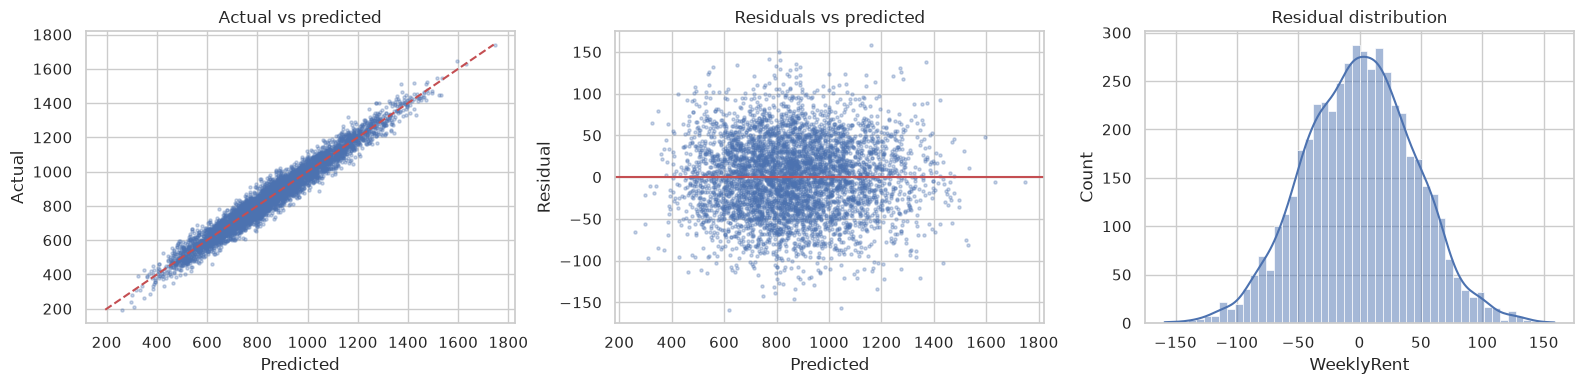

In [23]:
oof_pred = cross_val_predict(final_model, X, y, cv=cv, n_jobs=-1)
resid = y - oof_pred
print(f"Out-of-fold MSE of final model: {mean_squared_error(y, oof_pred):.4f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].scatter(oof_pred, y, s=5, alpha=0.3); ax[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--")
ax[0].set(xlabel="Predicted", ylabel="Actual", title="Actual vs predicted")
ax[1].scatter(oof_pred, resid, s=5, alpha=0.3); ax[1].axhline(0, color="r")
ax[1].set(xlabel="Predicted", ylabel="Residual", title="Residuals vs predicted")
sns.histplot(resid, bins=50, kde=True, ax=ax[2]).set_title("Residual distribution")
plt.tight_layout(); plt.show()

### 6.2 Test predictions

In [24]:
test_pred = final_model.predict(test_X[FEATURES])
submission = pd.DataFrame({"WeeklyRent": test_pred})

# Sanity checks required by the spec: one column named WeeklyRent, same length / order as the test file
assert list(submission.columns) == ["WeeklyRent"] and len(submission) == len(test_X)
submission.to_csv("SID_Assignment1_prediction.csv", index=False)   # TODO: replace SID
submission.describe().T

,count,mean,std,min,25%,50%,75%,max
WeeklyRent,1000.0000,854.9024,214.5254,362.0026,696.6234,837.2152,1005.0989,1536.0136


## 7. Marker-only cell
The final cell loads the complete test set and prints the test MSE of `final_model`.
**It is intentionally not executed**, because `WeeklyRent_test.csv` is only available to the marker.

In [ ]:
import pandas as pd
WeeklyRent_test = pd.read_csv("WeeklyRent_test.csv")
# YOUR CODE HERE: code that produces the test MSE test_error
y_test_pred = final_model.predict(WeeklyRent_test[FEATURES])
test_error = ((WeeklyRent_test["WeeklyRent"] - y_test_pred) ** 2).mean()
print(test_error)